<a href="https://colab.research.google.com/github/ropdxm/dimash-qurt-classifier/blob/main/mainv2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
! [ -e /content ] && pip install -Uqq fastbook
import fastbook
fastbook.setup_book()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 719.8/719.8 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 22.4 MB/s eta 0:00:00
Mounted at /content/gdrive


In [2]:
from fastbook import *
from fastai.vision.widgets import *
from fastai.vision.all import *
from pathlib import Path
import os, json, random, shutil, hashlib


In [3]:
!  pip install -U ddgs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 32.3 MB/s eta 0:00:00


In [33]:
BASE_PATH = Path("data_dimash_qurtt")
RAW_PATH  = BASE_PATH / "raw"
SPLIT_PATH = BASE_PATH / "split"

RAW_PATH.mkdir(parents=True, exist_ok=True)
SPLIT_PATH.mkdir(parents=True, exist_ok=True)

dimash_queries = [
    "Dimash Kudaibergen face",
    "Dimash Qudaibergen portrait",
    "Dimash Kudaibergen interview close-up",
    "Димаш Кудайберген фото",
    "Димаш Құдайберген портрет",
]

qurt_queries = [
    "qurt kazakh snack",
    "kazakh qurt food",
    "qurut dried yogurt balls",
    "kurut snack central asia",
    "құрт тағам",
    "құрт қазақша",
    "курт казахский продукт",
]


In [34]:
!pip -q install -U ddgs imagehash

from ddgs import DDGS
from ddgs.exceptions import DDGSException
from time import sleep
import imagehash
from PIL import Image

def ddgs_images_retry(query, max_results=100, tries=3, pause_base=3):
    """
    Runs DDGS image search with retry/backoff.
    Returns a list of image URLs.
    """
    for attempt in range(tries):
        try:
            with DDGS(timeout=20) as ddgs:
                results = list(ddgs.images(query, max_results=max_results))
                urls = [r["image"] for r in results if isinstance(r, dict) and r.get("image")]
                if urls:
                    return urls
        except DDGSException as e:
            print(f"Attempt {attempt+1}/{tries} failed for '{query}' -> {e}")
        except Exception as e:
            print(f"Attempt {attempt+1}/{tries} failed for '{query}' -> {type(e).__name__}: {e}")
        sleep(pause_base * (attempt + 1))

    print(f"DDGS failed for query: {query} -> No usable results.")
    return []

def normalize_url(url):
    return url.split("?")[0].strip()

def unique_urls(urls):
    seen, out = set(), []
    for u in urls:
        if not u:
            continue
        key = normalize_url(u)
        if key not in seen:
            seen.add(key)
            out.append(u)
    return out

def save_urls(urls, out_file):
    out_file = Path(out_file)
    out_file.write_text(json.dumps(urls, indent=2, ensure_ascii=False), encoding="utf-8")

def load_urls(in_file):
    in_file = Path(in_file)
    if not in_file.exists():
        return []
    return json.loads(in_file.read_text(encoding="utf-8"))

def collect_urls_for_class(class_name, queries, target=300, per_query=100):
    """
    Collect URLs across many queries until target is reached.
    """
    url_file = BASE_PATH / f"{class_name}_urls.json"
    urls = unique_urls(load_urls(url_file))

    print(f"\n=== Collecting URLs for {class_name} ===")
    print(f"Starting with {len(urls)} existing URLs")

    queries = list(queries)
    random.shuffle(queries)

    for q in queries:
        if len(urls) >= target:
            break

        new_urls = ddgs_images_retry(q, max_results=per_query, tries=DDGS_TRIES)
        urls = unique_urls(urls + new_urls)

        save_urls(urls, url_file)
        print(f"{len(urls):4d} urls after: {q}")
        sleep(PAUSE_BETWEEN_QUERIES)

    print(f"Finished {class_name}: {len(urls)} unique URLs")
    return urls[:target]

def download_class_images(class_name, urls, raw_path):
    """
    Download images into RAW_PATH/class_name
    """
    class_path = raw_path / class_name
    class_path.mkdir(parents=True, exist_ok=True)

    print(f"\n=== Downloading {class_name} images ===")
    download_images(class_path, urls=urls, max_pics=len(urls), preserve_filename=False)
    return class_path

def remove_broken_images(folder):
    files = get_image_files(folder)
    failed = verify_images(files)

    if len(failed):
        print(f"Removing {len(failed)} broken images from {folder.name}")
        for f in failed:
            try:
                f.unlink()
            except Exception as e:
                print(f"Could not remove {f}: {e}")
    else:
        print(f"No broken images found in {folder.name}")

def exact_file_hash(fp):
    h = hashlib.sha256()
    with open(fp, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            h.update(chunk)
    return h.hexdigest()

def dedupe_exact_and_near(folder, phash_threshold=6):
    """
    Remove exact duplicates and very similar near-duplicates.
    This is important when many web search results are reposts/crops of the same image.
    """
    files = list(get_image_files(folder))
    if not files:
        return

    # exact duplicate removal
    exact_seen = {}
    exact_removed = 0
    kept_files = []

    for f in files:
        try:
            key = exact_file_hash(f)
        except Exception:
            continue

        if key in exact_seen:
            f.unlink(missing_ok=True)
            exact_removed += 1
        else:
            exact_seen[key] = f
            kept_files.append(f)

    # near-duplicate removal via perceptual hash
    near_removed = 0
    kept_hashes = []

    for f in list(get_image_files(folder)):
        try:
            ph = imagehash.phash(Image.open(f).convert("RGB"))
        except Exception:
            continue

        is_dup = any(abs(ph - prev) <= phash_threshold for prev in kept_hashes)
        if is_dup:
            f.unlink(missing_ok=True)
            near_removed += 1
        else:
            kept_hashes.append(ph)

    print(f"{folder.name}: removed {exact_removed} exact duplicates and {near_removed} near-duplicates")

def make_split_folders(source_root, split_root, valid_pct=0.15, test_pct=0.15, seed=42):
    """
    Create train/valid/test folders explicitly so validation/test are truly held out.
    """
    random.seed(seed)

    if split_root.exists():
        shutil.rmtree(split_root)
    split_root.mkdir(parents=True, exist_ok=True)

    for cls_dir in sorted([p for p in source_root.iterdir() if p.is_dir()]):
        files = list(get_image_files(cls_dir))
        random.shuffle(files)

        n = len(files)
        n_test = max(1, int(n * test_pct))
        n_valid = max(1, int(n * valid_pct))

        test_files  = files[:n_test]
        valid_files = files[n_test:n_test+n_valid]
        train_files = files[n_test+n_valid:]

        for split_name, split_files in {
            "train": train_files,
            "valid": valid_files,
            "test": test_files
        }.items():
            dst = split_root / split_name / cls_dir.name
            dst.mkdir(parents=True, exist_ok=True)
            for f in split_files:
                shutil.copy2(f, dst / f.name)

    print(f"Created explicit split at: {split_root}")

def print_counts(root):
    print("\n=== Counts ===")
    for split in ["raw", "train", "valid", "test"]:
        split_dir = root / split if split != "raw" else RAW_PATH
        if split == "raw":
            base = RAW_PATH
            if base.exists():
                print(f"\n[{split}]")
                for cls in sorted([p.name for p in base.iterdir() if p.is_dir()]):
                    print(f"{cls:>8}: {len(get_image_files(base/cls))}")
        else:
            base = SPLIT_PATH / split
            if base.exists():
                print(f"\n[{split}]")
                for cls in sorted([p.name for p in base.iterdir() if p.is_dir()]):
                    print(f"{cls:>8}: {len(get_image_files(base/cls))}")


In [35]:

TARGET_PER_CLASS = 150
MAX_RESULTS_PER_QUERY = 50
PAUSE_BETWEEN_QUERIES = 2.5
DDGS_TRIES = 3

dimash_urls = collect_urls_for_class(
    "dimash",
    dimash_queries,
    target=TARGET_PER_CLASS,
    per_query=MAX_RESULTS_PER_QUERY
)

qurt_urls = collect_urls_for_class(
    "qurt",
    qurt_queries,
    target=TARGET_PER_CLASS,
    per_query=MAX_RESULTS_PER_QUERY
)

len(dimash_urls), len(qurt_urls)


=== Collecting URLs for dimash ===
Starting with 0 existing URLs
Attempt 1/3 failed for 'Димаш Кудайберген фото' -> No results found.
Attempt 2/3 failed for 'Димаш Кудайберген фото' -> No results found.
Attempt 3/3 failed for 'Димаш Кудайберген фото' -> No results found.
DDGS failed for query: Димаш Кудайберген фото -> No usable results.
   0 urls after: Димаш Кудайберген фото
Attempt 1/3 failed for 'Dimash Kudaibergen face' -> No results found.
Attempt 2/3 failed for 'Dimash Kudaibergen face' -> No results found.
Attempt 3/3 failed for 'Dimash Kudaibergen face' -> No results found.
DDGS failed for query: Dimash Kudaibergen face -> No usable results.
   0 urls after: Dimash Kudaibergen face
Attempt 1/3 failed for 'Димаш Құдайберген портрет' -> No results found.
Attempt 2/3 failed for 'Димаш Құдайберген портрет' -> No results found.
  50 urls after: Димаш Құдайберген портрет
  96 urls after: Dimash Kudaibergen interview close-up
Attempt 1/3 failed for 'Dimash Qudaibergen portrait' -> N

(96, 98)

In [36]:
dimash_path = download_class_images("dimash", dimash_urls, RAW_PATH)
qurt_path   = download_class_images("qurt", qurt_urls, RAW_PATH)

remove_broken_images(dimash_path)
remove_broken_images(qurt_path)

# IMPORTANT: web images often contain reposts/crops of the same photo.
# Removing duplicates BEFORE splitting reduces leakage.
dedupe_exact_and_near(dimash_path, phash_threshold=6)
dedupe_exact_and_near(qurt_path, phash_threshold=6)

make_split_folders(RAW_PATH, SPLIT_PATH, valid_pct=0.15, test_pct=0.15, seed=42)
print_counts(BASE_PATH)



=== Downloading dimash images ===

=== Downloading qurt images ===
Removing 1 broken images from dimash
No broken images found in qurt
dimash: removed 0 exact duplicates and 0 near-duplicates
qurt: removed 0 exact duplicates and 1 near-duplicates
Created explicit split at: data_dimash_qurtt/split

=== Counts ===

[raw]
  dimash: 83
    qurt: 90

[train]
  dimash: 59
    qurt: 64

[valid]
  dimash: 12
    qurt: 13

[test]
  dimash: 12
    qurt: 13


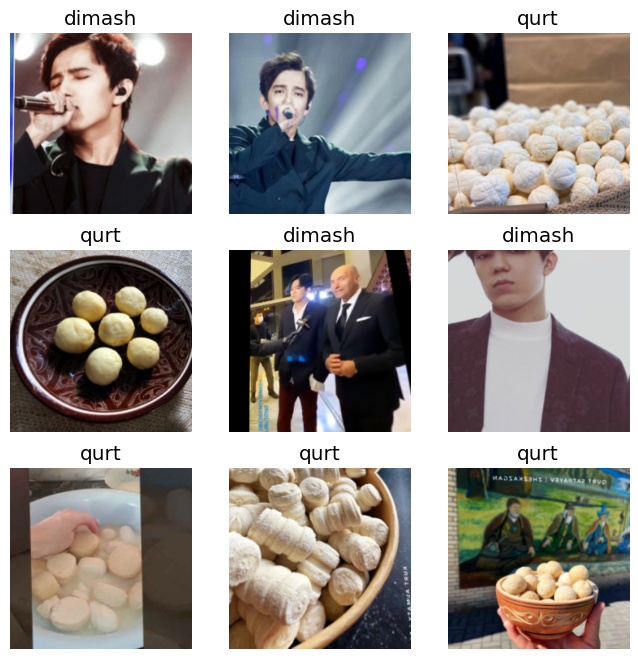

In [37]:
dls = ImageDataLoaders.from_folder(
    SPLIT_PATH,
    train='train',
    valid='valid',
    item_tfms=Resize(224),
    batch_tfms=aug_transforms(mult=1.0),
    bs=32
)

dls.show_batch(max_n=9, figsize=(8,8))


In [38]:
learn = vision_learner(dls, resnet18, metrics=[accuracy, error_rate])
learn.fine_tune(4)


epoch,train_loss,valid_loss,accuracy,error_rate,time
0,1.292474,0.243304,0.960000,0.040000,00:04


epoch,train_loss,valid_loss,accuracy,error_rate,time
0,0.241277,0.210886,0.920000,0.080000,00:04
1,0.223644,0.272011,0.880000,0.120000,00:03
2,0.172682,0.357585,0.880000,0.120000,00:02
3,0.141133,0.392884,0.880000,0.120000,00:02


<Axes: title={'center': 'learning curve'}, xlabel='steps', ylabel='loss'>

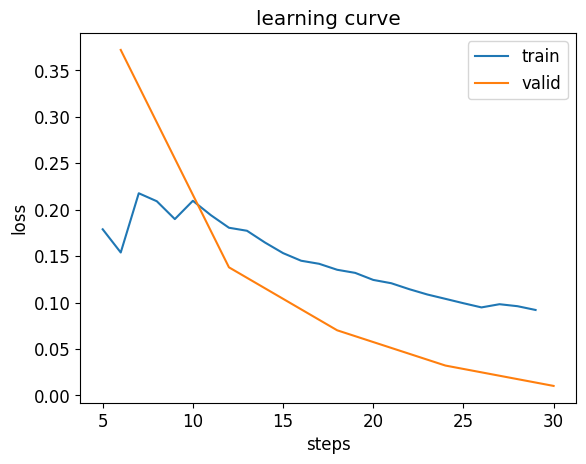

In [13]:
learn.recorder.plot_loss()

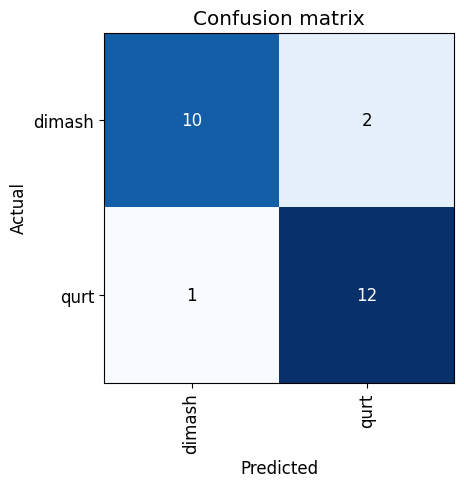

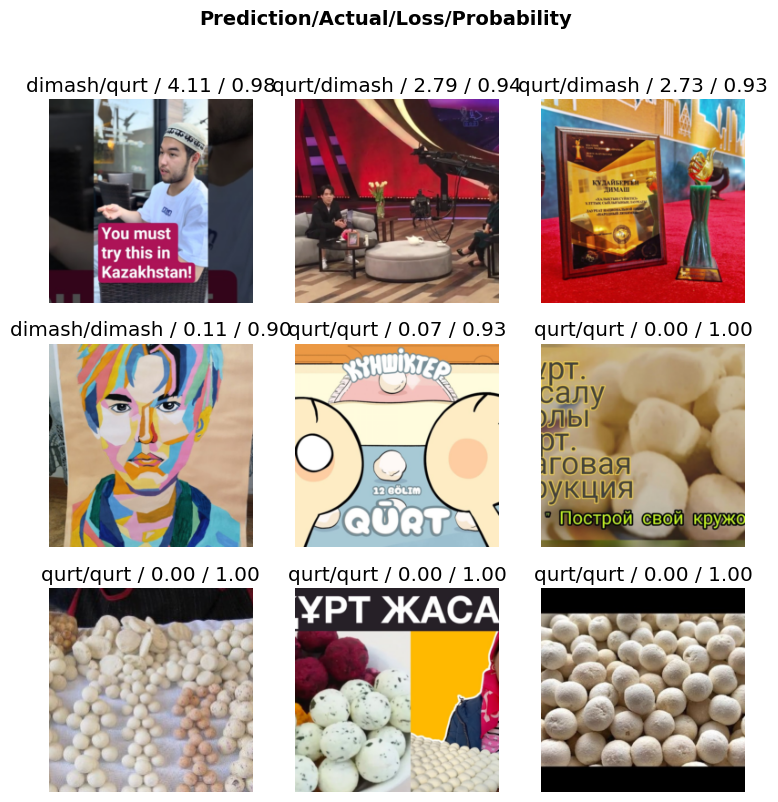

In [39]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()
interp.plot_top_losses(9, nrows=3)


In [40]:
# Evaluate on a truly unseen test set
test_files = get_image_files(SPLIT_PATH/'test')
test_dl = dls.test_dl(test_files, with_labels=True)
test_loss, test_acc, test_err = learn.validate(dl=test_dl)

print(f"Test loss:     {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test error:    {test_err:.4f}")


Test loss:     0.0009
Test accuracy: 1.0000
Test error:    0.0000


Prediction: qurt
Pred index: tensor(1)
Probabilities:
  dimash: 0.0003
  qurt: 0.9997


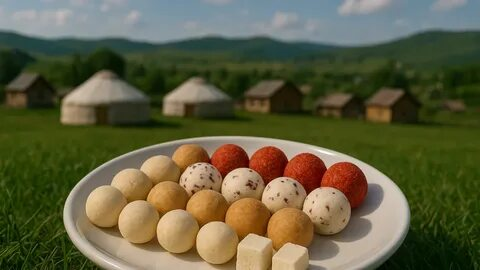

In [41]:
import requests

# This is only a demo prediction on one external image.
# It should NOT be used as your main quality metric.
url = "https://avatars.mds.yandex.net/i?id=534091866272147db548991c5bfff54b3cffa8d5-17444072-images-thumbs&n=13"
img_path = Path("/content/test_image.jpg")

r = requests.get(url, timeout=30)
r.raise_for_status()
img_path.write_bytes(r.content)

img = PILImage.create(img_path)
pred, pred_idx, probs = learn.predict(img)

print("Prediction:", pred)
print("Pred index:", pred_idx)
print("Probabilities:")
for label, p in zip(learn.dls.vocab, probs):
    print(f"  {label}: {float(p):.4f}")
img


In [42]:
learn.export('dimash_qurt_classifier2.pkl')

main problem seems to be fixed (the accuracy is not 100%)